In [2]:
import os, urllib.request
os.makedirs('Data', exist_ok=True)
url = 'https://github.com/maziarraissi/PINNs/raw/master/main/Data/NLS.mat'
path = 'Data/NLS.mat'
if not os.path.exists(path):
  urllib.request.urlretrieve(url, path)
  print('Downloaded NLS.mat')
else:
  print('NLS.mat already exists')

Downloaded NLS.mat


In [3]:
import numpy as np
import scipy.io
import torch
import torch.nn as nn
from scipy.interpolate import griddata #interpolate scattered data points in regular grid
from scipy.stats import qmc #latin hypercube sampling - generates N points in a d-dimensional unit hypercube
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import time

In [4]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'using device: {DEVICE}')

using device: cuda


In [5]:
#helper function to convert to tensor
def to_tensor(x, grad=False): #added the grad since there may be constants such as ub and lb
  return torch.tensor(x, dtype=torch.float32, device=DEVICE, requires_grad=grad)

In [18]:
class NLS_Net(nn.Module):
  def __init__(self, layers, lb, ub):
    super().__init__()
    self.lb = to_tensor(lb)
    self.ub = to_tensor(ub) #dont need grad since they are constants
    net = []
    for i in range(len(layers) - 2): #-2 since it builds hidden layer not output layer
      linear = nn.Linear(layers[i], layers[i+1]) # nn.Linear(in, out)
      #choosing initial value of weight and biases
      nn.init.xavier_normal_(linear.weight) #used xavier_normal: draws weights from normal dist, keeps variance of activation constant
      nn.init.zeros_(linear.bias)#used zeroes, keeps initial biases to zeroes
      #imp: _ after a operator means the operation is in place and modifies tensors, doesn't return a new value
      net.append(linear)
      net.append(nn.Tanh()) #chose tanh since it's smooth and as it is in the paper
    last = nn.Linear(layers[-2], layers[-1])
    nn.init.xavier_normal_(last.weight)
    nn.init.zeros_(last.bias)
    net.append(last)
    self.net = nn.Sequential(*net)

  def forward(self, x, t):
    X = torch.cat([x, t], dim=1)
    H = 2.0 * (X - self.lb) / (self.ub - self.lb) - 1.0
    out = self.net(H) #parses H over the network to procude tensor of shape (N, 2)
    u = out[:, 0:1]
    v = out[:, 1:2]
    return u, v

In [16]:
class PhysicsInformedNN:
  def __init__(self, x0, u0, v0, tb, X_f, layers, lb, ub):
    #x0 = spatial locations of initial condition samples
    #u0, v0 = real and imaginary part of the wave at t = 0 at x0
    #tb = time values at boundary condition
    #X_f = collocation points [x,t] for PDE

    X0 = np.hstack([x0, np.zeros_like(x0)])
    X_lb = np.hstack([np.full_like(tb, lb[0]), tb])
    X_ub = np.hstack([np.full_like(tb, ub[0]), tb])

    self.x0 = to_tensor(X0[:, 0:1])
    self.t0 = to_tensor(X0[:, 1:2]) # Corrected to 1:2 for time component
    self.u0 = to_tensor(u0)
    self.v0 = to_tensor(v0)

    self.x_lb = to_tensor(X_lb[:, 0:1], grad=True)
    self.t_lb = to_tensor(X_lb[:, 1:2], grad=True)
    self.x_ub = to_tensor(X_ub[:, 0:1], grad=True)
    self.t_ub = to_tensor(X_ub[:, 1:2], grad=True)

    self.x_f = to_tensor(X_f[:, 0:1], grad=True)
    self.t_f = to_tensor(X_f[:, 1:2], grad=True)

    self.model = NLS_Net(layers, lb, ub).to(DEVICE)
    self.optimizer_adam = torch.optim.Adam(self.model.parameters(), lr=0.001) # Renamed to optimizer_adam for consistency

  def net_uv(self, x, t):
    u, v = self.model(x,t)
    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    v_x = torch.autograd.grad(v, x, torch.ones_like(v), create_graph=True)[0]

    return u,v, u_x, v_x

  def net_f_uv(self, x, t):
    u, v, u_x, v_x = self.net_uv(x, t)
    u_t = torch.autograd.grad(u, t,torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    v_t = torch.autograd.grad(v, t, torch.ones_like(v), create_graph=True)[0] # Fixed 'craeate_graph' typo
    v_xx = torch.autograd.grad(v_x, x, torch.ones_like(v_x), create_graph=True)[0]
    f_u = u_t + (u * u_x) + (v * v_x)
    f_v = v_t + (u * v_x) + (v * v_xx)
    return f_u, f_v

  def loss_fn(self):
    mse = nn.MSELoss()
    u0_pred, v0_pred = self.model(self.x0, self.t0)
    loss_ic = mse(u0_pred, self.u0) + mse(v0_pred, self.v0)
    u_lb, v_lb, u_x_lb, v_x_lb = self.net_uv(self.x_lb, self.t_lb)
    u_ub, v_ub, u_x_ub, v_x_ub = self.net_uv(self.x_ub, self.t_ub)
    loss_bc = (mse(u_lb, u_ub) + mse(v_lb, v_ub) + mse(u_x_lb, u_x_ub) + mse(v_x_lb, v_x_ub))
    f_u, f_v = self.net_f_uv(self.x_f, self.t_f)
    loss_PDE = mse(f_u, torch.zeros_like(f_u)) + mse(f_v, torch.zeros_like(f_v)) # Fixed 'touch' typo to 'torch'
    return loss_ic + loss_bc + loss_PDE

  def train(self, n_adam=50000):
        print(f'=== Adam phase: {n_adam} iterations ===')
        self.model.train()
        t0 = time.time()
        for it in range(1, n_adam + 1):
            self.optimizer_adam.zero_grad()
            loss = self.loss_fn()
            loss.backward()
            self.optimizer_adam.step()
            if it % 1000 == 0:
                elapsed = time.time() - t0
                print(f'  Iter {it:6d}  Loss: {loss.item():.4e}  '
                      f'Time: {elapsed:.1f}s')
                t0 = time.time()


        print('\n=== L-BFGS-B phase ===')
        optimizer_lbfgs = torch.optim.LBFGS(
            self.model.parameters(),
            max_iter=50000,
            max_eval=50000,
            tolerance_grad=1e-7,
            tolerance_change=1e-9,
            history_size=50,
            line_search_fn='strong_wolfe'
        )
        call_count = [0]
        def closure():
            optimizer_lbfgs.zero_grad()
            loss = self.loss_fn()
            loss.backward()
            call_count[0] += 1
            if call_count[0] % 500 == 0:
                print(f'  L-BFGS call {call_count[0]:5d}  Loss: {loss.item():.4e}')
            return loss

        optimizer_lbfgs.step(closure)
        print('L-BFGS done.')

  def predict(self, X_star):
        self.model.eval()
        with torch.no_grad():
            x = to_tensor(X_star[:, 0:1])
            t = to_tensor(X_star[:, 1:2])
            u, v = self.model(x, t)
        # PDE residuals need gradients
        x_g = to_tensor(X_star[:, 0:1], grad=True)
        t_g = to_tensor(X_star[:, 1:2], grad=True)
        f_u, f_v = self.net_f_uv(x_g, t_g)
        return (u.cpu().numpy(),
                v.cpu().numpy(),
                f_u.detach().cpu().numpy(),
                f_v.detach().cpu().numpy())

In [8]:
def net_uv(self, x, t):
  u, v = self.model(x,t)
  u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
  v_x = torch.autograd.grad(v, x, torch.ones_like(v), create_graph=True)[0]

  return u,v, u_x, v_x

In [9]:
def net_f_uv(self, x, t):
  u, v, u_x, v_x = self.net_uv(x, t)
  u_t = torch.autograd.grad(u, t,torch.ones_like(u), create_graph=True)[0]
  u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
  v_t = torch.autograd.grad(v, t, torch.ones_like(v), craeate_graph=True)[0]
  v_xx = torch.autograd.grad(v_x, x, torch.ones_like(v_x), create_graph=True)[0]
  f_u = u_t + (u * u_x) + (v * v_x)
  f_v = v_t + (u * v_x) + (v * v_xx)
  return f_u, f_v

In [10]:
def loss_fn(self):
  mse = nn.MSELoss()
  u0_pred, v0_pred = self.model(self.x0, self.t0)
  loss_ic = mse(u0_pred, self.u0) + mse(v0_pred, self.v0)
  u_lb, v_lb, u_x_lb, v_x_lb = self.net_uv(self.x_lb, self.t_lb)
  u_ub, v_ub, u_x_ub, v_x_ub = self.net_uv(self.x_ub, self.t_ub)
  loss_bc = (mse(u_lb, u_ub) + mse(v_lb, v_ub) + mse(u_x_lb, u_x_ub) + mse(v_x_lb, v_x_ub))
  f_u, f_v = self.net_f_uv(self.x_f, self.t_f)
  loss_PDE = mse(f_u, torch.zeros_like(f_u)) + mse(f_v, touch.zeros_like(f_v))
  return loss_ic + loss_bc + loss_PDE


In [11]:
  def train(self, n_adam=50000):
        print(f'=== Adam phase: {n_adam} iterations ===')
        self.model.train()
        t0 = time.time()
        for it in range(1, n_adam + 1):
            self.optimizer_adam.zero_grad()
            loss = self.loss_fn()
            loss.backward()
            self.optimizer_adam.step()
            if it % 1000 == 0:
                elapsed = time.time() - t0
                print(f'  Iter {it:6d}  Loss: {loss.item():.4e}  '
                      f'Time: {elapsed:.1f}s')
                t0 = time.time()


        print('\n=== L-BFGS-B phase ===')
        optimizer_lbfgs = torch.optim.LBFGS(
            self.model.parameters(),
            max_iter=50000,
            max_eval=50000,
            tolerance_grad=1e-7,
            tolerance_change=1e-9,
            history_size=50,
            line_search_fn='strong_wolfe'
        )
        call_count = [0]
        def closure():
            optimizer_lbfgs.zero_grad()
            loss = self.loss_fn()
            loss.backward()
            call_count[0] += 1
            if call_count[0] % 500 == 0:
                print(f'  L-BFGS call {call_count[0]:5d}  Loss: {loss.item():.4e}')
            return loss

        optimizer_lbfgs.step(closure)
        print('L-BFGS done.')

  def predict(self, X_star):
        self.model.eval()
        with torch.no_grad():
            x = to_tensor(X_star[:, 0:1])
            t = to_tensor(X_star[:, 1:2])
            u, v = self.model(x, t)
        # PDE residuals need gradients
        x_g = to_tensor(X_star[:, 0:1], grad=True)
        t_g = to_tensor(X_star[:, 1:2], grad=True)
        f_u, f_v = self.net_f_uv(x_g, t_g)
        return (u.cpu().numpy(),
                v.cpu().numpy(),
                f_u.detach().cpu().numpy(),
                f_v.detach().cpu().numpy())

In [14]:
lb = np.array([-5.0, 0.0])
ub = np.array([ 5.0, np.pi/2])

N0 = 50    # initial condition samples
N_b = 50   # boundary time samples
N_f = 20000  # collocation points
layers = [2, 100, 100, 100, 100, 2]

data = scipy.io.loadmat('Data/NLS.mat')
t = data['tt'].flatten()[:, None]   # (201, 1)
x = data['x'].flatten()[:, None]    # (256, 1)
Exact   = data['uu']                 # complex (256, 201)
Exact_u = np.real(Exact)
Exact_v = np.imag(Exact)
Exact_h = np.sqrt(Exact_u**2 + Exact_v**2)

X, T = np.meshgrid(x, t)            # (201, 256) each
X_star = np.hstack([X.flatten()[:, None], T.flatten()[:, None]])
u_star = Exact_u.T.flatten()[:, None]
v_star = Exact_v.T.flatten()[:, None]
h_star = Exact_h.T.flatten()[:, None]

# Sample initial condition
idx_x = np.random.choice(x.shape[0], N0, replace=False)
x0 = x[idx_x, :]
u0 = Exact_u[idx_x, 0:1]
v0 = Exact_v[idx_x, 0:1]

# Sample boundary times
idx_t = np.random.choice(t.shape[0], N_b, replace=False)
tb = t[idx_t, :]

# Latin hypercube collocation points
sampler = qmc.LatinHypercube(d=2)
X_f = lb + (ub - lb) * sampler.random(n=N_f)

print(f'x0: {x0.shape}, u0: {u0.shape}, tb: {tb.shape}, X_f: {X_f.shape}')

x0: (50, 1), u0: (50, 1), tb: (50, 1), X_f: (20000, 2)


In [20]:
model = PhysicsInformedNN(x0, u0, v0, tb, X_f, layers, lb, ub)

t_start = time.time()
model.train(n_adam=10000)
print(f'\nTotal training time: {time.time() - t_start:.1f}s')

=== Adam phase: 10000 iterations ===
  Iter   1000  Loss: 7.4322e-03  Time: 36.9s
  Iter   2000  Loss: 3.9145e-03  Time: 36.1s
  Iter   3000  Loss: 2.7956e-03  Time: 36.1s
  Iter   4000  Loss: 2.2284e-03  Time: 36.3s
  Iter   5000  Loss: 2.6057e-03  Time: 36.2s
  Iter   6000  Loss: 1.9125e-03  Time: 37.0s
  Iter   7000  Loss: 1.7608e-03  Time: 36.1s
  Iter   8000  Loss: 1.7372e-03  Time: 36.1s
  Iter   9000  Loss: 1.9125e-03  Time: 36.1s
  Iter  10000  Loss: 1.6011e-03  Time: 36.1s

=== L-BFGS-B phase ===
  L-BFGS call   500  Loss: 1.4432e-03
  L-BFGS call  1000  Loss: 1.3242e-03
  L-BFGS call  1500  Loss: 1.2567e-03
  L-BFGS call  2000  Loss: 1.2123e-03
  L-BFGS call  2500  Loss: 1.1762e-03
  L-BFGS call  3000  Loss: 1.1451e-03
  L-BFGS call  3500  Loss: 1.1170e-03
L-BFGS done.

Total training time: 537.2s


In [22]:
u_pred, v_pred, f_u_pred, f_v_pred = model.predict(X_star)
h_pred = np.sqrt(u_pred**2 + v_pred**2)

error_u = np.linalg.norm(u_star - u_pred) / np.linalg.norm(u_star)
error_v = np.linalg.norm(v_star - v_pred) / np.linalg.norm(v_star)
error_h = np.linalg.norm(h_star - h_pred) / np.linalg.norm(h_star)
print(f'Relative L2 error — u: {error_u:.4e},  v: {error_v:.4e},  |h|: {error_h:.4e}')

Relative L2 error — u: 1.0436e+00,  v: 9.9976e-01,  |h|: 5.9847e-01


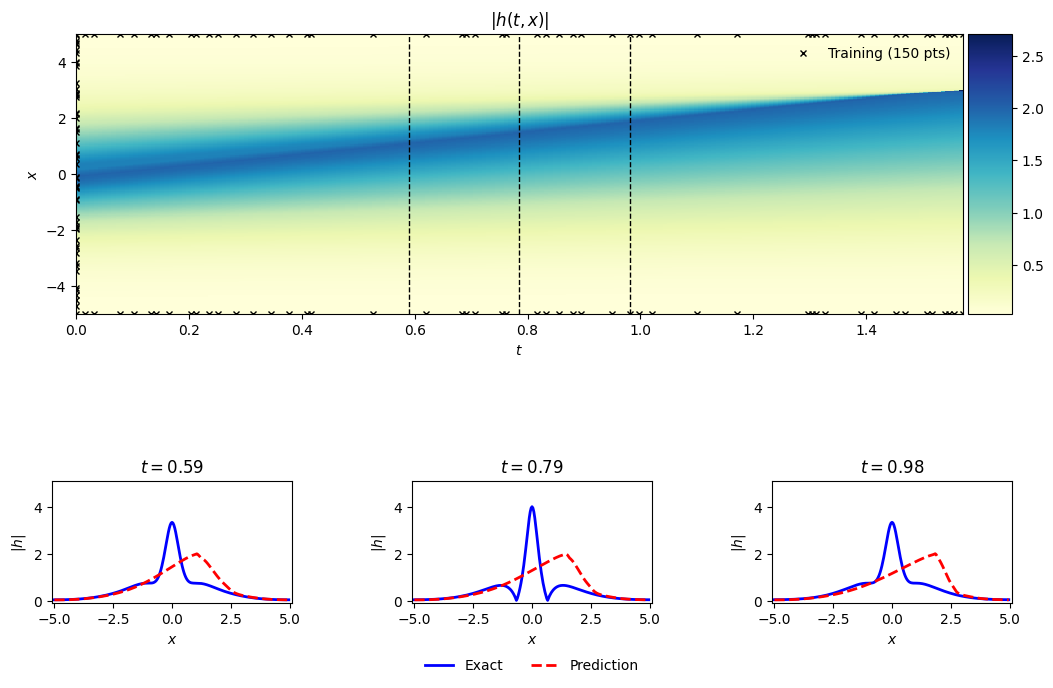

Saved NLS_result.png


In [23]:
# ── Plot results ──────────────────────────────────────────────────────────────
H_pred = griddata(X_star, h_pred.flatten(), (X, T), method='cubic')

X0_plot  = np.hstack([x0,  np.zeros_like(x0)])
X_lb_plot = np.hstack([np.full_like(tb, lb[0]), tb])
X_ub_plot = np.hstack([np.full_like(tb, ub[0]), tb])
X_u_train = np.vstack([X0_plot, X_lb_plot, X_ub_plot])

fig = plt.figure(figsize=(12, 8))

# ── Top: |h(x,t)| heatmap
gs0 = gridspec.GridSpec(1, 2)
gs0.update(top=0.9, bottom=0.55, left=0.12, right=0.9, wspace=0)
ax = fig.add_subplot(gs0[:, :])
im = ax.imshow(H_pred.T, interpolation='nearest', cmap='YlGnBu',
               extent=[lb[1], ub[1], lb[0], ub[0]],
               origin='lower', aspect='auto')
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(im, cax=cax)
ax.plot(X_u_train[:, 1], X_u_train[:, 0], 'kx',
        label=f'Training ({X_u_train.shape[0]} pts)', markersize=4)
for ti in [75, 100, 125]:
    ax.plot(t[ti]*np.ones(2), [x.min(), x.max()], 'k--', lw=1)
ax.set_xlabel('$t$'); ax.set_ylabel('$x$')
ax.legend(frameon=False, loc='best')
ax.set_title('$|h(t,x)|$')

# ── Bottom: three time slices
gs1 = gridspec.GridSpec(1, 3)
gs1.update(top=0.45, bottom=0.08, left=0.1, right=0.9, wspace=0.5)
for col, ti in enumerate([75, 100, 125]):
    ax = fig.add_subplot(gs1[0, col])
    ax.plot(x, Exact_h[:, ti], 'b-', lw=2, label='Exact')
    ax.plot(x, H_pred[ti, :],  'r--', lw=2, label='Prediction')
    ax.set_xlabel('$x$'); ax.set_ylabel('$|h|$')
    ax.set_title(f'$t = {t[ti, 0]:.2f}$')
    ax.axis('square')
    ax.set_xlim([-5.1, 5.1]); ax.set_ylim([-0.1, 5.1])
    if col == 1:
        ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.35),
                  ncol=2, frameon=False)

plt.savefig('NLS_result.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved NLS_result.png')